In [6]:
import numpy as np
import pandas as pd
from gwosc import datasets
import matplotlib.pyplot as plt
import requests

steps to do
1. find datasets
2. take a chirp section
3. take the mass parameters and generate clean waveform
4. generate noise waveforms? 
5. compare with observed waveform

https://pypi.org/project/gwosc/  
https://gwosc.org/api/v1/docs/

api info-  
all the timelines for a dataset- `/timeline/segments/all/<dataset>/<GPS_start>/<duration>/`  
all available datasets- `/archive/<GPS_start>/<GPS_end>/json/`  
available timelines for a dataset- `/timeline/segments/all/<dataset>/<GPS_start>/<duration>/`  
all info- ` /archive/all/json/`

In [2]:
r = requests.get(
  "https://gwosc.org/eventapi/jsonfull/allevents/")
gwData = r.json()["events"]['GW250207_115645-v1']

In [3]:
gwData.keys()

dict_keys(['commonName', 'version', 'catalog.shortName', 'GPS', 'reference', 'jsonurl', 'strain', 'mass_1_source', 'mass_1_source_lower', 'mass_1_source_upper', 'mass_1_source_unit', 'mass_2_source', 'mass_2_source_lower', 'mass_2_source_upper', 'mass_2_source_unit', 'network_matched_filter_snr', 'network_matched_filter_snr_lower', 'network_matched_filter_snr_upper', 'network_matched_filter_snr_unit', 'luminosity_distance', 'luminosity_distance_lower', 'luminosity_distance_upper', 'luminosity_distance_unit', 'chi_eff', 'chi_eff_lower', 'chi_eff_upper', 'chi_eff_unit', 'total_mass_source', 'total_mass_source_lower', 'total_mass_source_upper', 'total_mass_source_unit', 'chirp_mass_source', 'chirp_mass_source_lower', 'chirp_mass_source_upper', 'chirp_mass_source_unit', 'chirp_mass', 'chirp_mass_lower', 'chirp_mass_upper', 'chirp_mass_unit', 'redshift', 'redshift_lower', 'redshift_upper', 'redshift_unit', 'far', 'far_lower', 'far_upper', 'far_unit', 'p_astro', 'p_astro_lower', 'p_astro_upp

In [4]:
gwData["commonName"]

'GW250207_115645'

In [5]:
mos = gwData["mass_1_source"]
mts = gwData["mass_2_source"]
fms = gwData["final_mass_source"]


Chirp mass: 28.56 Msun
Total mass: 65.80 Msun
f_start = 20.0 Hz, f_end (approx cutoff) = 60.1 Hz


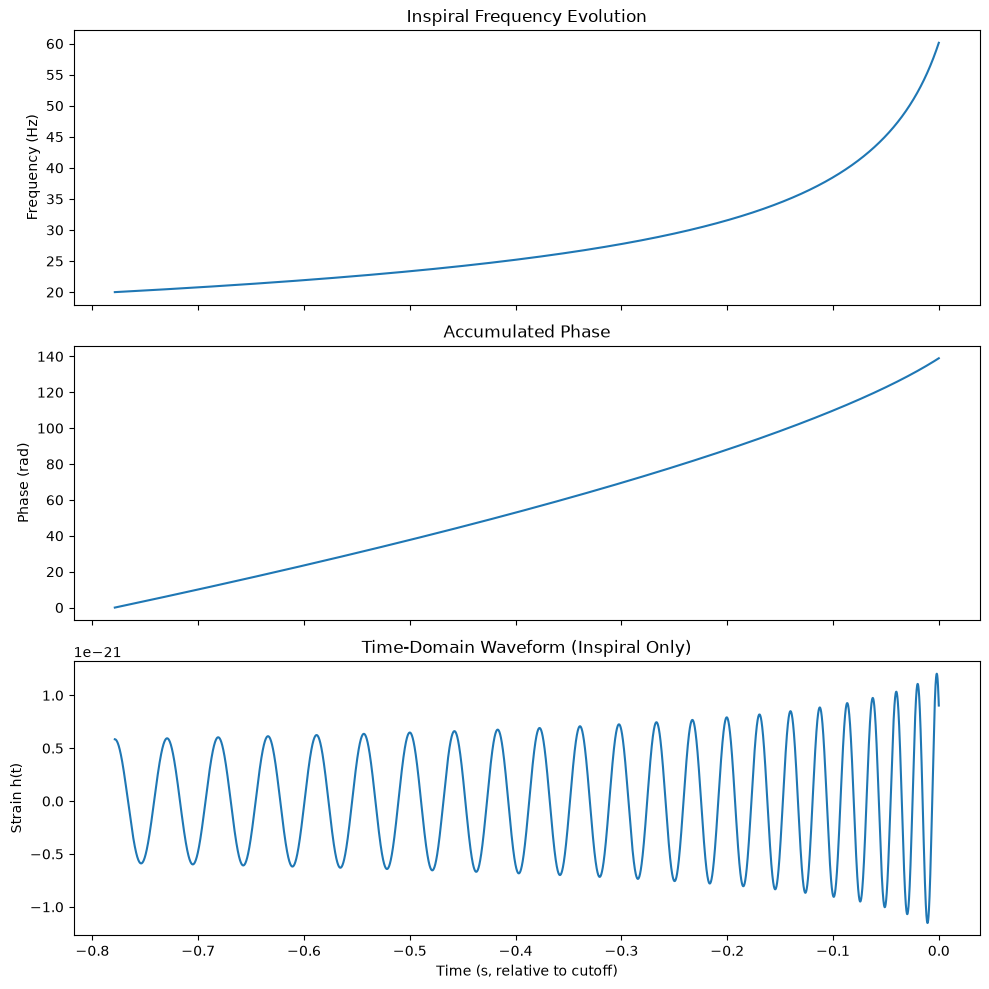

In [11]:
#generate clean waveform

G = 6.67430e-11
c = 2.99792458e8
Msun = 1.98892e30
Mpc = 3.0857e22  #meter

m1 = mos * Msun
m2 = mts * Msun
Mf = fms * Msun   

M = m1 + m2 #total mass
mu = (m1 * m2) / M #reduced mass
eta = mu / M #symmetric mass ratio
Mc = (m1 * m2)**(3/5) / M**(1/5) #chirp mass

#distance to source
D = 400 * Mpc

#freq
f_start = 20.0
f_isco = c**3 / (6**1.5 * np.pi * G * M)
f_end = 0.9 * f_isco

print(f"Chirp mass: {Mc/Msun:.2f} Msun")
print(f"Total mass: {M/Msun:.2f} Msun")
print(f"f_start = {f_start} Hz, f_end (approx cutoff) = {f_end:.1f} Hz")

#df/dt = (96/5) * pi^(8/3) * (G*Mc/c^3)^(5/3) * f^(11/3)
def dfdt(f):
    return (96/5) * np.pi**(8/3) * (G * Mc / c**3)**(5/3) * f**(11/3)

n_steps = 200000
f_array = np.linspace(f_start, f_end, n_steps)
df = f_array[1] - f_array[0]

dt_array = df / dfdt(f_array)
t_array = np.cumsum(dt_array)
t_array -= t_array[-1]

phase_array = 2 * np.pi * np.cumsum(f_array * dt_array)

#A(t) ∝ (G*Mc/c^2)^(5/3) * (pi*f/c)^(2/3) / D
A_array = (4 / D) * (G * Mc / c**2)**(5/3) * (np.pi * f_array / c)**(2/3)

#strain waveform
h_array = A_array * np.cos(phase_array)

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t_array, f_array)
axs[0].set_ylabel("Frequency (Hz)")
axs[0].set_title("Inspiral Frequency Evolution")

axs[1].plot(t_array, phase_array)
axs[1].set_ylabel("Phase (rad)")
axs[1].set_title("Accumulated Phase")

axs[2].plot(t_array, h_array)
axs[2].set_ylabel("Strain h(t)")
axs[2].set_xlabel("Time (s, relative to cutoff)")
axs[2].set_title("Time-Domain Waveform (Inspiral Only)")

plt.tight_layout()
plt.savefig('figures/frequency_evolution.png', dpi=150, bbox_inches='tight')
plt.show()